# Athlete Lifelogging — Full Pipeline
**Sections :** Chargement → Food Images (CNN) → Agrégation → EDA → Prétraitement → Modélisation → Export


## 0. Imports & Configuration

In [1]:
import os, json, re, warnings, sys
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
from datetime import datetime

from sklearn.impute import SimpleImputer
from sklearn.metrics import (
    roc_auc_score,
    roc_curve,
    confusion_matrix,
)

from transformers import pipeline as hf_pipeline
from imblearn.over_sampling import SMOTE

warnings.filterwarnings('ignore')
pd.set_option('display.max_columns', 40)
sns.set_theme(style='whitegrid')
plt.rcParams['figure.dpi'] = 100

PROJECT_ROOT = Path.cwd()
SRC_PATH = PROJECT_ROOT / 'src'
if str(SRC_PATH) not in sys.path:
    sys.path.insert(0, str(SRC_PATH))

from athlete_pipeline.utils.io import load_json, load_csv, load_participants
from athlete_pipeline.utils.parsing import (
    parse_minute_series,
    parse_resting_hr,
    parse_hr_zones,
    parse_sleep,
    parse_exercise,
    parse_injury,
    parse_srpe,
    parse_wellness,
    parse_reporting,
)
from athlete_pipeline.utils.imaging import (
    get_food_images,
    classify_image,
    load_food_cache,
    save_food_cache,
)
from athlete_pipeline.config.constants import CACHE_FILE
from athlete_pipeline.features.engineering import (
    winsorize,
    add_acwr,
    add_temporal_features,
    build_perf_index,
)
from athlete_pipeline.models.injury import add_injury_target, train_injury_model
from athlete_pipeline.models.performance import train_perf_model

print('✅ Imports OK')


✅ Imports OK


In [ ]:
DATA_ROOT = Path(r"C:\Users\you\Downloads\your-data-folder")
# DATA_ROOT = "/home/you/data/athlete-data"              # macOS / Linux
PARTICIPANTS = sorted([
    d.name for d in DATA_ROOT.iterdir()
    if d.is_dir() and re.match(r'^p\d+$', d.name)
])

print(f"Participants trouvés : {PARTICIPANTS}")


Participants trouvés : ['p01', 'p03', 'p05']


## 1. Chargement des données

In [3]:
participants_df = load_participants(DATA_ROOT / 'participant-overview.xlsx')
participants_df.head()

,age,height_cm,gender,group,max_hr,date_5km,min_5km,sec_5km,stride_walk,stride_run
participant_id,,,,,,,,,,
p01,48,195,male,A,182.0,2019-11-26 00:00:00,29,33,80.9,102.9
p02,60,180,male,A,169.0,2019-12-15 00:00:00,23,51,74.7,92.4
p03,25,184,male,A,157.0,2019-12-30 00:00:00,33,22,NaN,NaN
p04,26,163,female,A,195.0,2019-11-19 00:00:00,22,13,67.3,110.2
p05,35,176,male,A,184.0,2019-12-23 00:00:00,32,40,73.0,94.3


## 2. Analyse nutritionnelle — CNN Food-101

In [4]:
# ── Load CNN model ────────────────────────────────────────────
food_clf = None
print('Loading model (downloads ~330MB on first run)...')
try:
    food_clf = hf_pipeline(
        'image-classification',
        model='nateraw/food',
        top_k=3,
    )
    print('✅ Model ready')
except Exception as e:
    print(f'⚠️  Could not load model: {e}')

# ── Process all participants (with cache) ─────────────────────
cache = load_food_cache(CACHE_FILE)

food_rows = []
for pid in PARTICIPANTS:
    imgs = get_food_images(DATA_ROOT / pid)
    for img in imgs:
        key = f"{pid}_{img['filename']}"
        if key not in cache:
            cache[key] = classify_image(img['path'], food_clf)
        row = {**{'participant_id': pid, 'date': img['date']}, **cache[key]}
        food_rows.append(row)
    print(f'  {pid}: {len(imgs)} images')

save_food_cache(cache, CACHE_FILE)

food_raw = pd.DataFrame(food_rows)
print(f'✅ {len(food_raw)} food records | cache: {len(cache)} entries')
food_raw.head(6)

Loading model (downloads ~330MB on first run)...


Loading weights:   0%|          | 0/200 [00:00<?, ?it/s]

The image processor of type `ViTImageProcessor` is now loaded as a fast processor by default, even if the model checkpoint was saved with a slow processor. This is a breaking change and may produce slightly different outputs. To continue using the slow processor, instantiate this class with `use_fast=False`. 


✅ Model ready
  p01: 320 images
  p03: 136 images
  p05: 186 images
✅ 642 food records | cache: 642 entries


,participant_id,date,food_class,confidence,area_ratio,portion_g,calories_kcal,protein_g,carbs_g,fat_g,fiber_g,method
0,p01,2020-02-01,peking_duck,0.586,0.197,78.7,265,14.9,0.0,22.0,0.0,cnn_food101
1,p01,2020-02-01,waffles,0.175,0.209,83.6,293,8.4,33.4,12.5,2.5,fallback_average
2,p01,2020-02-01,edamame,0.460,0.388,116.5,142,12.8,10.5,5.8,6.1,cnn_food101
3,p01,2020-02-01,pizza,0.967,0.314,125.4,334,13.8,41.4,12.5,2.5,cnn_food101
4,p01,2020-02-01,frozen_yogurt,0.151,0.203,81.3,285,8.1,32.5,12.2,2.4,fallback_average
5,p01,2020-02-01,apple_pie,0.311,0.362,108.5,257,2.6,36.7,11.9,1.5,cnn_food101


In [6]:
# ── Aggregate to daily totals ─────────────────────────────────
if not food_raw.empty:
    food_raw['date'] = pd.to_datetime(food_raw['date']).dt.date
    food_daily = food_raw.groupby(['participant_id','date']).agg(
        total_kcal_consumed = ('calories_kcal','sum'),
        total_protein_g     = ('protein_g','sum'),
        total_carbs_g       = ('carbs_g','sum'),
        total_fat_g         = ('fat_g','sum'),
        n_food_photos       = ('filename' if 'filename' in food_raw.columns else 'food_class','count'),
        mean_confidence     = ('confidence','mean'),
    ).reset_index()
    print(f"Daily nutrition: {len(food_daily)} rows")
    display(food_daily.head())
else:
    food_daily = pd.DataFrame()
    print("No food data.")


Daily nutrition: 158 rows


,participant_id,date,total_kcal_consumed,total_protein_g,total_carbs_g,total_fat_g,n_food_photos,mean_confidence
0,p01,2020-02-01,1934,65.4,191.9,97.8,7,0.428571
1,p01,2020-02-02,1503,55.0,145.6,76.3,6,0.390500
2,p01,2020-02-03,2938,96.3,333.3,126.1,9,0.382111
3,p01,2020-02-04,2055,79.9,167.5,111.9,6,0.510333
4,p01,2020-02-05,1575,51.7,134.8,89.0,5,0.330200


## 3. Agrégation journalière

In [7]:
def build_daily(pid, root, food_daily=None):
    fb  = root / pid / 'fitbit'
    gd  = root / pid / 'googledocs'
    pm  = root / pid / 'pmsys'

    sources = [
        parse_minute_series(load_json(fb/'calories.json'), 'total_calories_burned'),
        parse_minute_series(load_json(fb/'distance.json'), 'distance_cm'),
        parse_minute_series(load_json(fb/'steps.json'),    'total_steps'),
        parse_resting_hr(load_json(fb/'resting_heart_rate.json')),
        parse_hr_zones(load_json(fb/'time_in_heart_rate_zones.json')),
        parse_sleep(load_json(fb/'sleep.json')),
        parse_exercise(load_json(fb/'exercise.json')),
        parse_reporting(load_csv(gd/'reporting.csv')),
        parse_srpe(load_csv(pm/'srpe.csv')),
        parse_wellness(load_csv(pm/'wellness.csv')),
        parse_injury(load_csv(pm/'injury.csv')),
    ]

    # sleep score
    sc = load_csv(fb/'sleep_score.csv', parse_dates=['timestamp'])
    if not sc.empty:
        sc['date'] = sc['timestamp'].dt.date
        sc = sc.rename(columns={'overall_score':'sleep_score'})[['date','sleep_score']]
        sources.append(sc)

    sources = [s for s in sources if s is not None and not s.empty]
    if not sources: return pd.DataFrame()

    base = sources[0]
    for s in sources[1:]:
        base = pd.merge(base, s, on='date', how='outer')

    # merge food
    if food_daily is not None and not food_daily.empty:
        pf = food_daily[food_daily['participant_id']==pid].copy()
        if not pf.empty:
            pf['date'] = pd.to_datetime(pf['date']).dt.date
            base = pd.merge(base, pf.drop(columns='participant_id'), on='date', how='left')

    base['participant_id'] = pid
    base['date'] = pd.to_datetime(base['date'])
    return base.sort_values('date').reset_index(drop=True)


all_dfs = []
for pid in PARTICIPANTS:
    df_p = build_daily(pid, DATA_ROOT,
                     food_daily=food_daily if not food_daily.empty else None)
    if df_p.empty: continue
    if pid in participants_df.index:
        for col in ['age','height_cm','gender','group','max_hr']:
            df_p[col] = participants_df.loc[pid, col]
    all_dfs.append(df_p)
    print(f"{pid}: {len(df_p)} days")

df = pd.concat(all_dfs, ignore_index=True)
print(f"✅ Combined dataset: {df.shape}")


p01: 161 days
p03: 157 days
p05: 161 days
✅ Combined dataset: (479, 45)


## 4. Exploration des données (EDA)

                    start        end  days
participant_id                            
p01            2019-11-01 2020-03-31   161
p03            2019-11-01 2020-03-31   157
p05            2019-11-01 2020-03-31   161


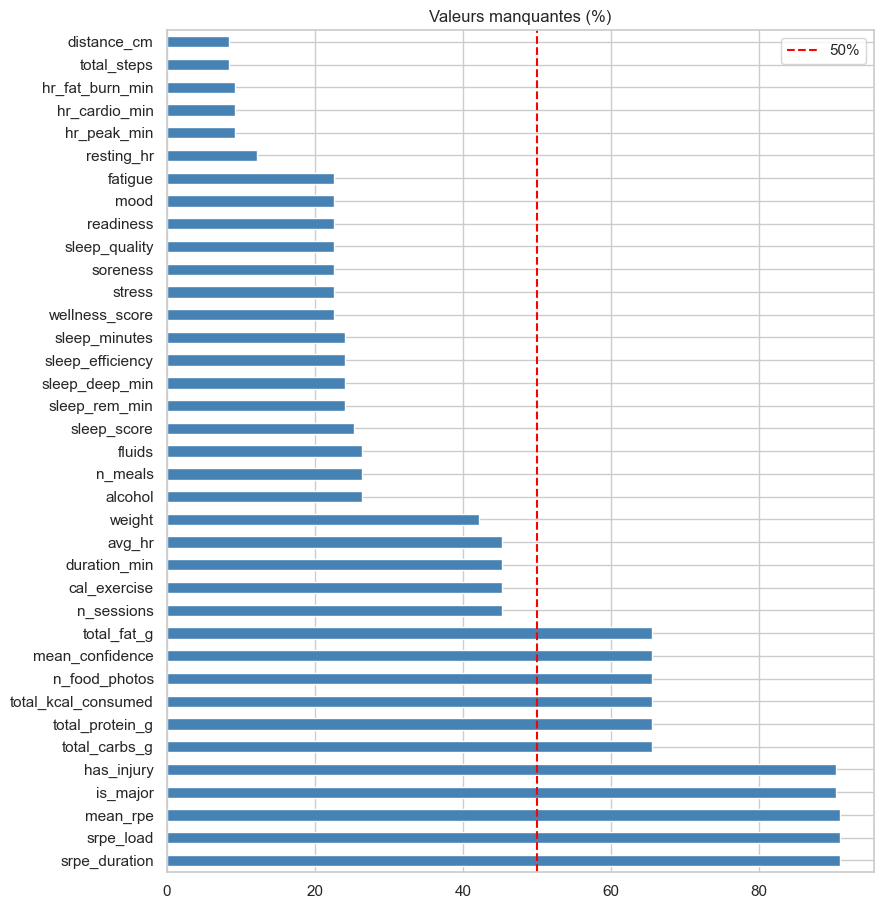

In [8]:
# ── Overview ─────────────────────────────────────────────────
print(df.groupby('participant_id')['date'].agg(['min','max','count'])
       .rename(columns={'min':'start','max':'end','count':'days'}))

# ── Missing values ────────────────────────────────────────────
miss = (df.isnull().mean() * 100).sort_values(ascending=False)
miss = miss[miss > 0]
fig, ax = plt.subplots(figsize=(9, max(3, len(miss)*0.25)))
miss.plot(kind='barh', ax=ax, color='steelblue')
ax.axvline(50, color='red', linestyle='--', label='50%')
ax.set_title("Valeurs manquantes (%)"); ax.legend()
plt.tight_layout(); plt.show()


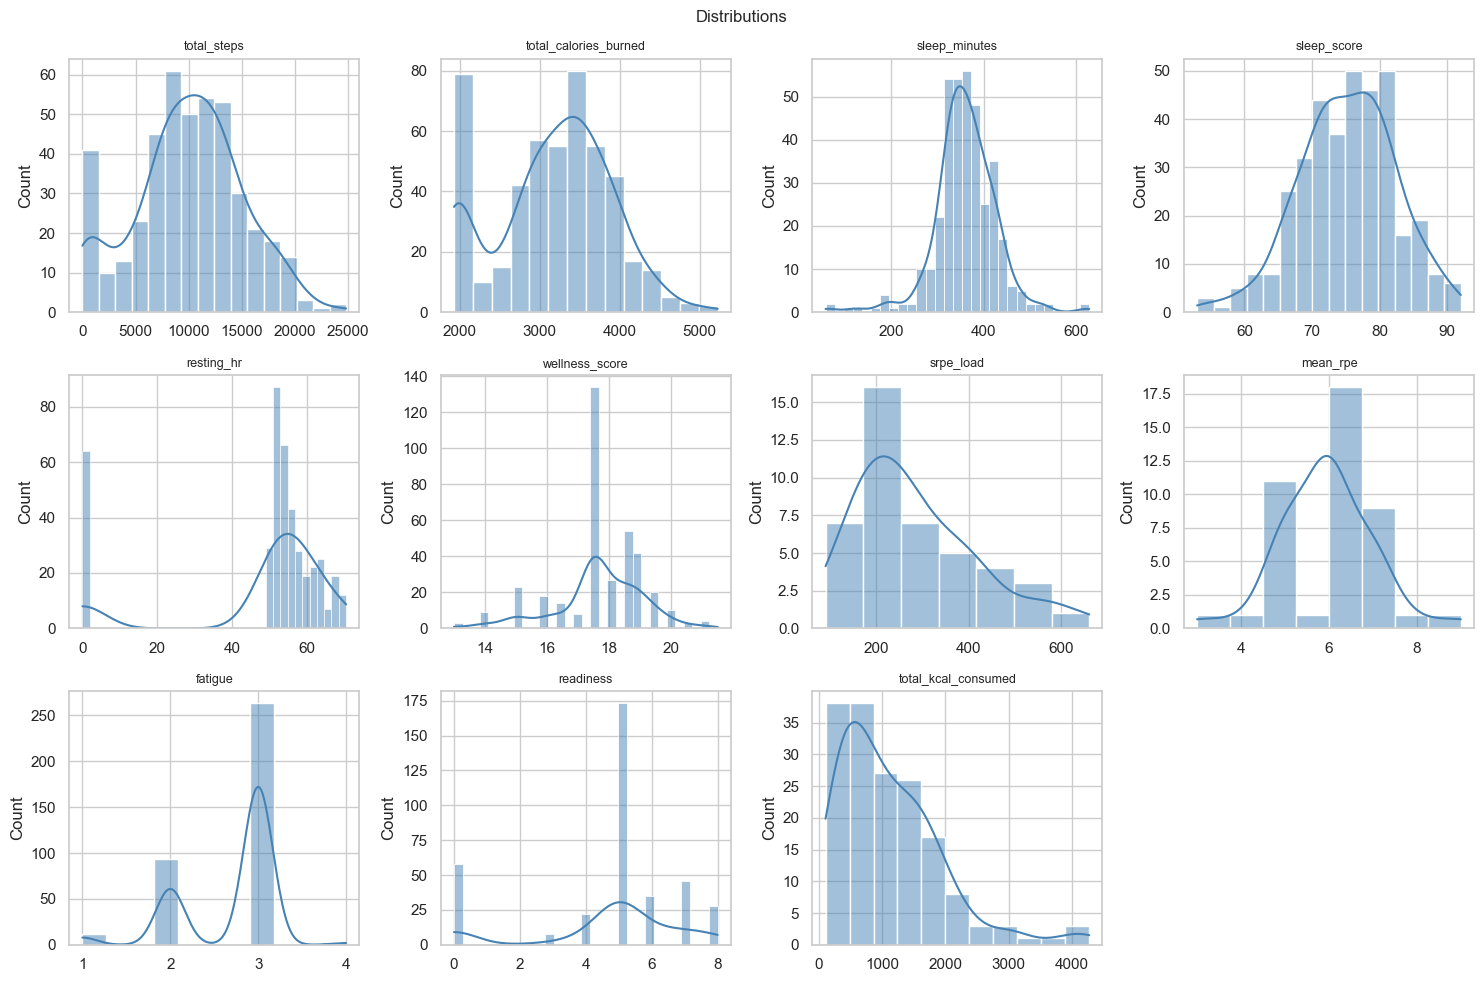

In [9]:
# ── Key distributions ─────────────────────────────────────────
key_vars = [c for c in ['total_steps','total_calories_burned','sleep_minutes',
    'sleep_score','resting_hr','wellness_score','srpe_load','mean_rpe',
    'fatigue','readiness','total_kcal_consumed'] if c in df.columns]

fig, axes = plt.subplots(3, 4, figsize=(15, 10))
axes = axes.flatten()
for i, col in enumerate(key_vars):
    sns.histplot(df[col].dropna(), kde=True, ax=axes[i], color='steelblue')
    axes[i].set_title(col, fontsize=9); axes[i].set_xlabel('')
for j in range(i+1, len(axes)):
    axes[j].set_visible(False)
plt.suptitle("Distributions", fontsize=12); plt.tight_layout(); plt.show()


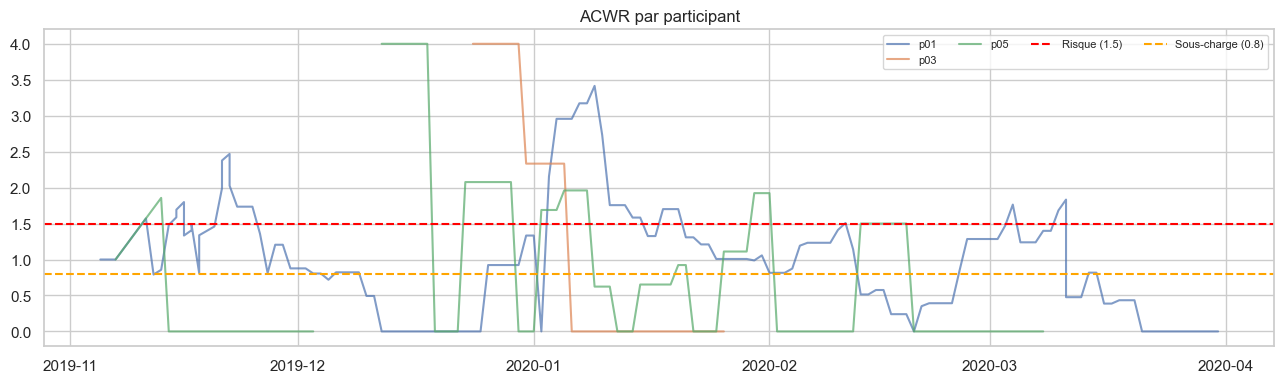

In [10]:
# ── ACWR (Acute:Chronic Workload Ratio) ───────────────────────
# Gabbett (2016): ratio > 1.5 = injury risk, < 0.8 = under-training
df = add_acwr(df)

fig, ax = plt.subplots(figsize=(13, 4))
for pid, grp in df.groupby('participant_id'):
    ax.plot(grp['date'], grp['acwr'], alpha=0.7, label=pid)
ax.axhline(1.5, color='red',    linestyle='--', label='Risque (1.5)')
ax.axhline(0.8, color='orange', linestyle='--', label='Sous-charge (0.8)')
ax.set_title("ACWR par participant"); ax.legend(fontsize=8, ncol=4)
plt.tight_layout(); plt.show()


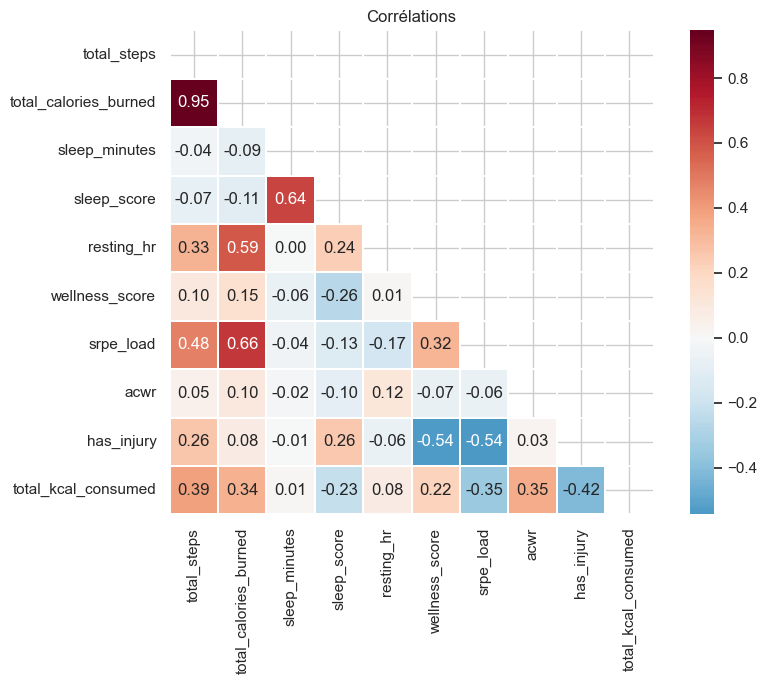

In [11]:
# ── Correlation matrix ────────────────────────────────────────
corr_cols = [c for c in ['total_steps','total_calories_burned','sleep_minutes',
    'sleep_score','resting_hr','wellness_score','srpe_load','acwr','has_injury',
    'total_kcal_consumed'] if c in df.columns]

fig, ax = plt.subplots(figsize=(9, 7))
sns.heatmap(df[corr_cols].corr(), annot=True, fmt='.2f', cmap='RdBu_r',
            center=0, square=True, linewidths=0.3, ax=ax,
            mask=np.triu(np.ones((len(corr_cols),len(corr_cols)),dtype=bool)))
ax.set_title("Corrélations"); plt.tight_layout(); plt.show()


## 5. Prétraitement

In [12]:
df['date'] = pd.to_datetime(df['date'])
if 'gender' in df.columns:
    df['gender_enc'] = df['gender'].map({'male':0,'female':1,'m':0,'f':1})
if 'group' in df.columns:
    df['group_enc'] = df['group'].str.strip().map({'A':0,'B':1})
for col in ['has_injury','is_major']:
    if col in df.columns:
        df[col] = df[col].fillna(0).astype(int)

outlier_cols = [c for c in ['total_steps','total_calories_burned','resting_hr',
    'sleep_minutes','srpe_load','duration_min','total_kcal_consumed'] if c in df.columns]

for col in outlier_cols:
    df[col] = winsorize(df[col])

# ── Missing value imputation ──────────────────────────────────
feat_num = [c for c in df.select_dtypes(include=np.number).columns]
miss_pct = df[feat_num].isnull().mean()

# 1. Drop columns > 60% missing
drop_cols = miss_pct[miss_pct > 0.60].index.tolist()
df_clean = df.drop(columns=drop_cols)
print(f"Dropped ({len(drop_cols)} cols > 60% missing): {drop_cols}")

feat_num2 = [c for c in df_clean.select_dtypes(include=np.number).columns]

# 2. Forward-fill slow-changing variables (per participant)
for col in ['weight','resting_hr','fluids']:
    if col in df_clean.columns:
        df_clean[col] = df_clean.groupby('participant_id')[col].transform(
            lambda x: x.ffill().bfill())

# 3. Median imputation for the rest
df_clean[feat_num2] = SimpleImputer(strategy='median').fit_transform(df_clean[feat_num2])

print(f"✅ Missing remaining: {df_clean.isnull().sum().sum()}")
print(f"   Shape: {df_clean.shape}")

Dropped (9 cols > 60% missing): ['mean_rpe', 'srpe_load', 'srpe_duration', 'total_kcal_consumed', 'total_protein_g', 'total_carbs_g', 'total_fat_g', 'n_food_photos', 'mean_confidence']
✅ Missing remaining: 0
   Shape: (479, 39)


## 6. Indice de performance (0–100)

Composite pondéré de 4 dimensions (littérature sportive) :

| Dimension | Poids | Source |
|---|---|---|
| Récupération (sleep + FC repos) | 30% | Mah et al. (2011) |
| Bien-être subjectif (wellness) | 30% | Hooper et al. (1995) |
| Charge optimale (ACWR) | 25% | Gabbett (2016) |
| Activité physique (pas) | 15% | Tudor-Locke (2004) |


count    479.0
mean      51.4
std       13.7
min       19.0
25%       39.0
50%       54.2
75%       62.5
max       77.1
Name: perf_index, dtype: float64


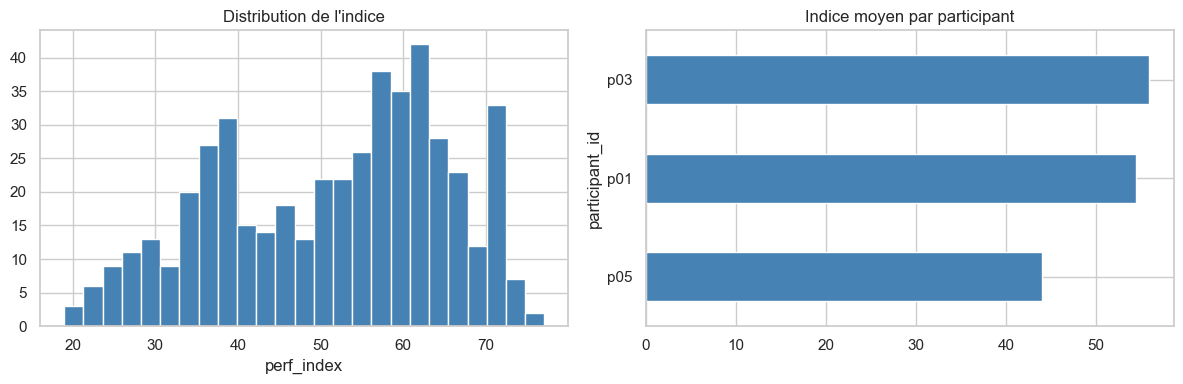

In [13]:
df_clean = build_perf_index(df_clean)
print(df_clean['perf_index'].describe().round(1))

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].hist(df_clean['perf_index'].dropna(), bins=25,
             color='steelblue', edgecolor='white')
axes[0].set_title("Distribution de l'indice")
axes[0].set_xlabel('perf_index')
df_clean.groupby('participant_id')['perf_index'].mean().sort_values().plot(
    kind='barh', ax=axes[1], color='steelblue', edgecolor='white'
)
axes[1].set_title('Indice moyen par participant')
plt.tight_layout()
plt.show()

## 7. Feature Engineering

In [14]:
# Rolling averages, lags, day_of_week — captures temporal dynamics
df_clean = add_temporal_features(df_clean)
print(f"✅ Feature engineering done — {df_clean.shape[1]} features")


✅ Feature engineering done — 53 features


## 8. Modèle 1 — Prédiction du risque de blessure (T+7 jours)

On prédit si l'athlète se blessera dans les **7 prochains jours**.
Métrique principale : **ROC-AUC** (robuste aux classes déséquilibrées).


In [15]:
# Target: injury in next 7 days (via module)
_, inj_parts = add_injury_target(df_clean)
df_injury_preview = pd.concat(inj_parts, ignore_index=True)

print('Target distribution:')
print(
    df_injury_preview['injury_next7d']
    .value_counts(normalize=True)
    .rename({0: 'No injury', 1: 'Injury'})
    .round(3)
)

Target distribution:
injury_next7d
No injury    0.894
Injury       0.106
Name: proportion, dtype: float64


In [16]:
injury_result = train_injury_model(df_clean, test_size=0.2, random_state=42, threshold=0.40)

# Keep the same variable names used by plotting cells
rf = injury_result['model']
feats = injury_result['features']
y_te = injury_result['y_true']
y_pred = injury_result['y_pred']
y_prob = injury_result['y_prob']

print(injury_result['classification_report'])
print(f"ROC-AUC : {injury_result['roc_auc']:.3f}")
print(
    f"CV ROC-AUC : {injury_result['cv_roc_auc_mean']:.3f} ± "
    f"{injury_result['cv_roc_auc_std']:.3f}"
)

  File "c:\Users\hayth\anaconda3\Lib\site-packages\joblib\externals\loky\backend\context.py", line 257, in _count_physical_cores
    cpu_info = subprocess.run(
               ^^^^^^^^^^^^^^^
  File "c:\Users\hayth\anaconda3\Lib\subprocess.py", line 548, in run
    with Popen(*popenargs, **kwargs) as process:
         ^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "c:\Users\hayth\anaconda3\Lib\subprocess.py", line 1026, in __init__
    self._execute_child(args, executable, preexec_fn, close_fds,
  File "c:\Users\hayth\anaconda3\Lib\subprocess.py", line 1538, in _execute_child
    hp, ht, pid, tid = _winapi.CreateProcess(executable, args,
                       ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^


              precision    recall  f1-score   support

   No injury       0.97      0.98      0.97        86
      Injury       0.78      0.70      0.74        10

    accuracy                           0.95        96
   macro avg       0.87      0.84      0.85        96
weighted avg       0.95      0.95      0.95        96

ROC-AUC : 0.992
CV ROC-AUC : 0.980 ± 0.012


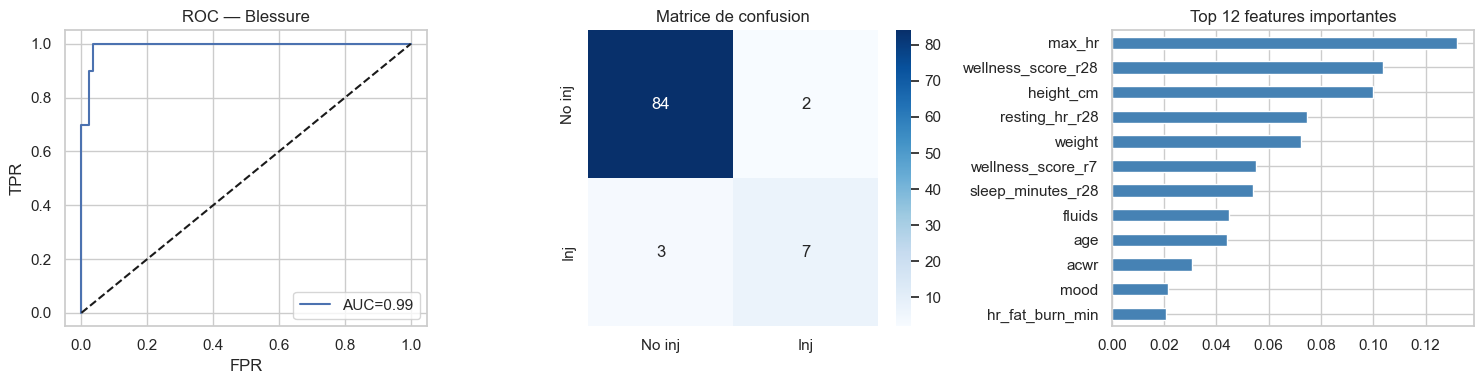

In [17]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

# ROC
fpr, tpr, _ = roc_curve(y_te, y_prob)
axes[0].plot(fpr, tpr, label=f"AUC={roc_auc_score(y_te,y_prob):.2f}")
axes[0].plot([0,1],[0,1],'k--'); axes[0].set_title("ROC — Blessure")
axes[0].set_xlabel("FPR"); axes[0].set_ylabel("TPR"); axes[0].legend()

# Confusion matrix
sns.heatmap(confusion_matrix(y_te, y_pred), annot=True, fmt='d',
            ax=axes[1], cmap='Blues',
            xticklabels=['No inj','Inj'], yticklabels=['No inj','Inj'])
axes[1].set_title("Matrice de confusion")

# Feature importance
pd.Series(rf.feature_importances_, index=feats).nlargest(12)  .sort_values().plot(kind='barh', ax=axes[2], color='steelblue')
axes[2].set_title("Top 12 features importantes")

plt.tight_layout(); plt.show()


## 9. Modèle 2 — Prédiction de la performance (J+1)

On prédit l'**indice de performance du lendemain** à partir des données du jour.


In [17]:
perf_result = train_perf_model(df_clean, test_size=0.2, random_state=42)

# Keep the same variable names used by plotting cells
gbr = perf_result['model']
yp_te = perf_result['y_true']
yp_pred = perf_result['y_pred']
perf_features = perf_result['features']

print(f"RMSE : {perf_result['rmse']:.2f}")
print(f"MAE  : {perf_result['mae']:.2f}")
print(f"R²   : {perf_result['r2']:.3f}")
print(
    f"CV R²: {perf_result['cv_r2_mean']:.3f} ± "
    f"{perf_result['cv_r2_std']:.3f}"
)

RMSE : 7.83
MAE  : 5.99
R²   : 0.674
CV R²: 0.468 ± 0.103


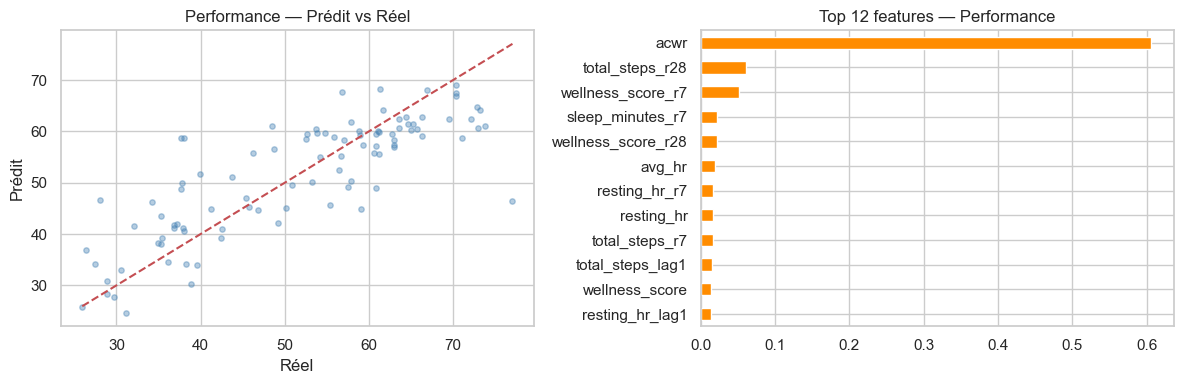

In [18]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].scatter(yp_te, yp_pred, alpha=0.4, s=15, color='steelblue')
lo, hi = yp_te.min(), yp_te.max()
axes[0].plot([lo, hi], [lo, hi], 'r--')
axes[0].set_xlabel('Réel')
axes[0].set_ylabel('Prédit')
axes[0].set_title('Performance — Prédit vs Réel')

pd.Series(gbr.feature_importances_, index=perf_features).nlargest(12).sort_values().plot(
    kind='barh', ax=axes[1], color='darkorange'
)
axes[1].set_title('Top 12 features — Performance')

plt.tight_layout()
plt.show()

## 10. Export — `test_dataset.csv`

In [19]:
export = df_clean.copy()
export['date'] = export['date'].astype(str)
export.to_csv("test_dataset.csv", index=False)
print(f"✅ test_dataset.csv saved — {export.shape[0]} rows × {export.shape[1]} cols")
export.head()


✅ test_dataset.csv saved — 479 rows × 53 cols


,date,total_calories_burned,distance_cm,total_steps,resting_hr,hr_fat_burn_min,hr_cardio_min,hr_peak_min,sleep_minutes,sleep_efficiency,sleep_deep_min,sleep_rem_min,n_sessions,cal_exercise,duration_min,avg_hr,weight,fluids,alcohol,n_meals,...,gender,group,max_hr,acwr,gender_enc,group_enc,perf_index,total_steps_r7,total_steps_r28,total_steps_lag1,resting_hr_r7,resting_hr_r28,resting_hr_lag1,wellness_score_r7,wellness_score_r28,wellness_score_lag1,sleep_minutes_r7,sleep_minutes_r28,sleep_minutes_lag1,day_of_week
0,2019-11-01,4009.10,1442400.0,17873.0,53.741074,164.0,3.0,0.0,359.5,96.0,54.0,69.0,2.0,494.0,58.9,94.0,100.0,7.0,0.0,3.0,...,male,A,182.0,0.815094,0.0,0.0,73.929224,17873.00,17873.00,10392.0,53.741074,53.741074,54.614599,19.500,19.500,17.5,359.500000,359.500000,359.5,4
1,2019-11-02,3533.56,1058480.0,13118.0,52.881497,137.0,0.0,0.0,378.0,97.0,36.0,83.0,1.0,354.0,41.0,98.0,100.0,7.0,0.0,3.0,...,male,A,182.0,0.815094,0.0,0.0,73.847795,15495.50,15495.50,17873.0,53.311285,53.311285,53.741074,19.750,19.750,19.5,368.750000,368.750000,359.5,5
2,2019-11-03,3748.73,1146085.0,14312.0,53.222024,141.0,0.0,0.0,378.0,96.0,38.0,51.0,1.0,349.0,39.7,103.0,100.0,7.0,0.0,3.0,...,male,A,182.0,0.815094,0.0,0.0,67.415695,15101.00,15101.00,13118.0,53.281532,53.281532,52.881497,19.500,19.500,20.0,371.833333,371.833333,378.0,6
3,2019-11-04,3353.38,885970.0,10970.0,54.311141,100.0,0.0,0.0,361.0,96.0,37.0,35.0,1.0,145.0,17.1,97.0,100.0,7.0,0.0,3.0,...,male,A,182.0,0.815094,0.0,0.0,63.466571,14068.25,14068.25,14312.0,53.538934,53.538934,53.222024,19.375,19.375,19.0,369.125000,369.125000,378.0,0
4,2019-11-05,3794.63,1371470.0,16186.0,52.259110,94.0,7.0,12.0,326.0,99.0,27.0,39.0,2.0,517.0,40.6,118.5,100.0,7.0,0.0,3.0,...,male,A,182.0,1.000000,0.0,0.0,69.837913,14491.80,14491.80,10970.0,53.282969,53.282969,54.311141,19.300,19.300,19.0,360.500000,360.500000,361.0,1
